# Axion PINN V9 — Restricted Collocation + Supervised Anchoring

## Diagnosis of V8 failure

The V8 architecture was correct: WKB phi gave exact C-ICs, ODE-calibrated a_net gave 0.4% pretrain error.
But physics training **completely destroyed both networks** because physics losses were 10²³−10²⁷.

**Root cause**: log-time τ parametrisation creates `dτ/dt = 1/(t·log_dt)` → ∞ as t→0.
Any smooth A(τ) with non-zero `d²A/dτ²(0)` maps to astronomical `d²A/dt²` at small-τ collocation points, producing gigantic `d²φ/dt²` in KG residuals. The pretrained solution is then obliterated by the resulting gradients.

## V9 Fixes

### Fix 1: Restricted collocation (τ ∈ [τ_min, 1.0])
At τ=0.7 (t ≈ 10⁻³), `dτ/dt ≈ 43.5` instead of `3.45×10⁸` at τ=0.01.
The `d²A/dt²` contribution to KG_loss drops from 10²⁷ to manageable O(0.01).
The pre-oscillation domain (τ < 0.7) is already well-satisfied by the pretrain.

### Fix 2: Supervised anchoring during physics training
Add a time-decaying supervised loss to prevent drift from pretrained solution:
```
L_total = L_F + λ_KG·L_KG + λ_anc(t)·[L_a_supervised + L_phi_supervised]
```
λ_anc decays from 1.0 → 0.01 over training (curriculum).

### Fix 3: Freeze a_net in early epochs
For first 5000 Adam epochs: only train phi_net on KG loss (a_net frozen).
This prevents the KG gradients from corrupting a during the difficult early phase.


In [1]:
"""Imports and global config — float64 throughout."""
import os, time, warnings
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.integrate import solve_ivp

DTYPE  = torch.float64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPS    = 1e-30
torch.set_default_dtype(DTYPE)

print(f"PyTorch {torch.__version__} | device={device} | dtype={DTYPE}")

# ── Physical parameters ────────────────────────────────────────────────────────
PARAMS = {
    'ma'     : 100.0,
    'rho_m0' : 0.81,
    'rho_r0' : 2.7138e-4,
    'rho_L'  : 2.19,
    'a0'     : 1e-8,
    'phi0'   : 1.0,
    'dphi0'  : 0.0,
    't_init' : 1e-10,
    't_end'  : 1.0,
}

# Pre-compute the log-time transformation constants
_LOG_T0  = np.log(PARAMS['t_init'])
_LOG_T1  = np.log(PARAMS['t_end'])
_LOG_DT  = _LOG_T1 - _LOG_T0   # denominator for τ normalisation

def t_to_tau(t_tensor):
    """Map t ∈ [t_init, t_end]  →  τ ∈ [0, 1]  (log-space normalisation)."""
    log_t = torch.log(torch.clamp(t_tensor, min=EPS))
    return (log_t - _LOG_T0) / _LOG_DT

def tau_to_t(tau_tensor):
    """Inverse: τ ∈ [0,1] → t ∈ [t_init, t_end]."""
    return torch.exp(_LOG_T0 + tau_tensor * _LOG_DT)

print("PARAMS and log-time helpers defined.")


PyTorch 2.12.0+cpu | device=cpu | dtype=torch.float64
PARAMS and log-time helpers defined.


In [2]:
# ── ODE reference and physics residuals ───────────────────────────────────────

def _ode_rhs(t, y, ma, rho_m0, rho_r0, rho_L):
    a, phi, phi_dot = y
    a_s   = max(a, 1e-30)
    rax   = 0.5*phi_dot**2 + 0.5*ma**2*phi**2
    E1    = rax + rho_m0/a_s   + rho_r0/a_s**2 + rho_L*a**2
    da_dt = np.sqrt(max(E1, 0.0)/3.0)
    E2    = rax + rho_m0/a_s**3 + rho_r0/a_s**4 + rho_L
    H2    = np.sqrt(max(E2, 0.0)/3.0)
    return [da_dt, phi_dot, -np.sqrt(3.0)*H2*phi_dot - ma**2*phi]


def solve_ode(params, n_eval=5000):
    t0 = params['t_init']; t1 = params['t_end']
    y0 = [params['a0'], params['phi0'], params['dphi0']]
    args = (params['ma'], params['rho_m0'], params['rho_r0'], params['rho_L'])
    t_eval = np.logspace(np.log10(t0), np.log10(t1), n_eval)
    print("Solving ODE reference (RK45)...")
    t_s = time.time()
    sol = solve_ivp(_ode_rhs, (t0, t1), y0, t_eval=t_eval,
                    method='RK45', rtol=1e-10, atol=1e-13, args=args)
    print(f"  Done {time.time()-t_s:.2f}s | success={sol.success}")
    if not sol.success: warnings.warn(sol.message)
    return sol


def physics_residuals(a, phi, a_t, phi_t, phi_tt, ma, rho_m0, rho_r0, rho_L):
    """Compute Friedmann and Klein-Gordon residuals."""
    sqrt3 = torch.tensor(3.0, dtype=DTYPE, device=a.device).sqrt()
    rax   = 0.5*phi_t**2 + 0.5*ma**2*phi**2
    a_s   = torch.clamp(a, min=EPS)
    # Eq 1 — Friedmann
    E1  = rax + rho_m0/a_s   + rho_r0/a_s**2 + rho_L*a**2
    H1  = torch.sqrt(torch.clamp(E1/3.0, min=0.0) + EPS)
    R_F = a_t - H1
    # Eq 2 — Klein-Gordon
    E2   = rax + rho_m0/a_s**3 + rho_r0/a_s**4 + rho_L
    H2   = torch.sqrt(torch.clamp(E2/3.0, min=0.0) + EPS)
    R_KG = phi_tt + sqrt3*H2*phi_t + ma**2*phi
    return R_F, R_KG


print("ODE + physics residuals defined.")


ODE + physics residuals defined.


## Architecture cells

**FCNN**: unchanged tanh MLP (input τ ∈ [0,1])

**ScaleFactorNet_V8**: a(t) = a₀·exp(clamp(τ·g(τ), max=40))  
Last linear bias initialised to 11.5 → g(τ)≈11.5 at init → log(a/a₀)≈11.5·τ (radiation-era approximation)

**PhiNet_V8**: φ(t) = (φ₀ + τ²·net_A(τ))·cos(m_a·t) + τ·net_B(τ)·sin(m_a·t)  
Exact hard ICs for both φ(t₀) and φ̇(t₀).

**AxionPINN_V8**: wraps both nets, computes τ = log_normalise(t) internally.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# FCNN (tanh) — same as V7, input τ ∈ [0,1]
# ─────────────────────────────────────────────────────────────────────────────
class FCNN(nn.Module):
    def __init__(self, in_dim=1, out_dim=1, hidden=64, depth=4):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, tau):
        return self.net(tau)


# ─────────────────────────────────────────────────────────────────────────────
# ScaleFactorNet_V8
#   a(t) = a₀ · exp(clamp(τ · g(τ), max=40))
#   Fix vs V7: last linear bias initialised to 11.5 so g(τ)≈11.5 at start
#   (radiation-era: log(a/a₀) ≈ ½·ln(t_end/t_init)·τ ≈ 11.5·τ)
# ─────────────────────────────────────────────────────────────────────────────
class ScaleFactorNet_V8(nn.Module):
    def __init__(self, a0, hidden=64, depth=4):
        super().__init__()
        self.register_buffer('log_a0', torch.tensor(np.log(float(a0)), dtype=DTYPE))
        self.net = FCNN(1, 1, hidden, depth)
        # Key fix: initialise last Linear bias to radiation-era slope
        _rad_slope = 0.5 * (_LOG_DT)  # = 0.5 * ln(t_end/t_init) ≈ 11.5
        for m in reversed(list(self.net.net.modules())):
            if isinstance(m, nn.Linear):
                nn.init.constant_(m.bias, _rad_slope)
                break

    def forward(self, tau):
        g = self.net(tau)
        return torch.exp(self.log_a0 + torch.clamp(tau * g, max=40.0))


# ─────────────────────────────────────────────────────────────────────────────
# PhiNet_V8 — WKB decomposition
#   φ(t) = A(τ) · cos(mₐ·t) + B(τ) · sin(mₐ·t)
#   A(τ) = φ₀ + τ² · net_A(τ)    [A(0)=φ₀, A′(0)=0]
#   B(τ) = τ · net_B(τ)           [B(0)=0]
#   Exact hard IC: φ(t₀) = φ₀, φ̇(t₀) = 0
# ─────────────────────────────────────────────────────────────────────────────
class PhiNet_V8(nn.Module):
    def __init__(self, phi0, ma, hidden=64, depth=4):
        super().__init__()
        self.register_buffer('phi0', torch.tensor(float(phi0), dtype=DTYPE))
        self.register_buffer('ma',   torch.tensor(float(ma),   dtype=DTYPE))
        self.net_A = FCNN(1, 1, hidden, depth)   # correction to amplitude A
        self.net_B = FCNN(1, 1, hidden, depth)   # coefficient of sin term B

    def forward(self, tau, t):
        """
        Args:
            tau : (N,1) log-normalised time ∈ [0,1]  — network input
            t   : (N,1) physical time                 — for cos/sin evaluation
        """
        A = self.phi0 + tau**2 * self.net_A(tau)
        B = tau * self.net_B(tau)
        ma_t = self.ma * t
        return A * torch.cos(ma_t) + B * torch.sin(ma_t)


# ─────────────────────────────────────────────────────────────────────────────
# AxionPINN_V8 — combined model
# ─────────────────────────────────────────────────────────────────────────────
class AxionPINN_V8(nn.Module):
    def __init__(self, params,
                 a_hidden=64,    a_depth=4,
                 phi_hidden=64,  phi_depth=4):
        super().__init__()
        self.register_buffer('_log_t0', torch.tensor(_LOG_T0, dtype=DTYPE))
        self.register_buffer('_log_dt', torch.tensor(_LOG_DT, dtype=DTYPE))
        self.a_net   = ScaleFactorNet_V8(params['a0'], a_hidden, a_depth)
        self.phi_net = PhiNet_V8(params['phi0'], params['ma'], phi_hidden, phi_depth)

    def _to_tau(self, t):
        return (torch.log(torch.clamp(t, min=EPS)) - self._log_t0) / self._log_dt

    def forward(self, t):
        tau = self._to_tau(t)
        a   = self.a_net(tau)
        phi = self.phi_net(tau, t)
        return a, phi


# ── Sanity check ──────────────────────────────────────────────────────────────
_t   = torch.tensor([[PARAMS['t_init']], [1e-5], [0.01], [1.0]], dtype=DTYPE)
_m   = AxionPINN_V8(PARAMS)
_a, _p = _m(_t)
print("V8 Architecture test:")
print(f"  a(t_init) = {_a[0,0].item():.4e}  (expected {PARAMS['a0']:.4e})")
print(f"  phi(t_init) = {_p[0,0].item():.6f}  (expected {PARAMS['phi0']:.6f})")

# Check initial a prediction (should be closer to ODE than V7 due to better init)
_tau = _m._to_tau(_t).detach().numpy().flatten()
_a_pred = _a.detach().numpy().flatten()
print(f"\nInitial a_net predictions (before pretrain):")
for ti, tau_i, a_i in zip([PARAMS['t_init'], 1e-5, 0.01, 1.0], _tau, _a_pred):
    rad_pred = PARAMS['a0'] * (ti / PARAMS['t_init'])**0.5
    print(f"  t={ti:.0e}: a_pred={a_i:.3e}, a_ODE(radiation)≈{rad_pred:.3e}")
del _t, _m, _a, _p

print("\nClasses defined: FCNN, ScaleFactorNet_V8, PhiNet_V8, AxionPINN_V8")


V8 Architecture test:
  a(t_init) = 1.0000e-08  (expected 1.0000e-08)
  phi(t_init) = 1.000000  (expected 1.000000)

Initial a_net predictions (before pretrain):
  t=1e-10: a_pred=1.000e-08, a_ODE(radiation)≈1.000e-08
  t=1e-05: a_pred=2.823e-06, a_ODE(radiation)≈3.162e-06
  t=1e-02: a_pred=7.544e-05, a_ODE(radiation)≈1.000e-04
  t=1e+00: a_pred=6.514e-04, a_ODE(radiation)≈1.000e-03

Classes defined: FCNN, ScaleFactorNet_V8, PhiNet_V8, AxionPINN_V8


## Solver — `AxionPINNSolver_V7`

**Three-phase training:**

| Phase | What | Loss |
|---|---|---|
| `pretrain_a`   | Supervised on ODE a(t) | log-MSE of predicted a vs ODE a |
| `pretrain_phi` | Supervised on ODE φ(t) | MSE of predicted h(τ) vs target h=(φ_ODE−φ₀−φ̇₀Δt)/Δt² |
| `adam + lbfgs` | Physics residuals | Weighted F+KG loss on τ-uniform collocation |

**Key changes vs V6:**
- Both nets pretrained → physics training starts near the true solution
- KG scale fixed as `phi_scale = max(|φ_ODE|)` — never updated dynamically  
- Collocation points sampled uniform in τ → `t = tau_to_t(τ)`, then `.requires_grad_(True)`


In [4]:
class AxionPINNSolver_V9:
    """
    V9: WKB phi_net + ODE-calibrated a_net + restricted collocation + supervised anchoring.

    Key changes from V8:
      1. Collocation sampled from tau ~ Uniform[tau_min, 1.0] (default tau_min=0.7)
         → avoids log-time singularity at small tau that caused 10^27 physics losses
      2. Supervised anchoring term during physics training (decaying lambda)
         → prevents drift from pretrained solution
      3. Freeze a_net during early Adam epochs (KG-only phase)
         → prevents KG gradients from destroying a_net
    """
    def __init__(self, params,
                 n_colloc=2000,
                 a_hidden=64,   a_depth=4,
                 phi_hidden=64, phi_depth=4):
        self.params   = params
        self.n_colloc = n_colloc
        self.model    = AxionPINN_V8(params, a_hidden, a_depth, phi_hidden, phi_depth)
        sol = solve_ode(params)
        self.t_ode   = sol.t
        self.a_ode   = sol.y[0]
        self.phi_ode = sol.y[1]
        self.phi_scale = max(float(np.max(np.abs(self.phi_ode))), 1e-4)
        self.loss_hist = {'f': [], 'kg': [], 'anc': [], 'total': []}

        # ODE-calibrated a_net initialisation
        t_ref_np  = self.t_ode[:, None].astype(np.float64)
        t_tensor  = torch.tensor(t_ref_np, dtype=DTYPE)
        with torch.no_grad():
            tau_np = self.model._to_tau(t_tensor).numpy().flatten()
        f_tau  = np.log(self.a_ode / params['a0'])
        g_init = float(np.sum(tau_np * f_tau) / np.sum(tau_np**2))
        print(f"  g_init = {g_init:.3f}")
        for m in reversed(list(self.model.a_net.net.net.modules())):
            if isinstance(m, nn.Linear):
                nn.init.constant_(m.bias, g_init)
                break

    # ──────────────────────────────────────────────────────────────────────────
    # Pretrain (same as V8)
    # ──────────────────────────────────────────────────────────────────────────
    def pretrain_a_net(self, epochs=8000, lr=1e-3, print_every=1000):
        opt = torch.optim.Adam(self.model.a_net.parameters(), lr=lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
        t_ref   = torch.tensor(self.t_ode[:, None], dtype=DTYPE)
        a_ref   = torch.tensor(self.a_ode[:, None], dtype=DTYPE)
        tau_ref = self.model._to_tau(t_ref).detach()
        print("=== Phase 1: Pretrain a_net ===")
        for ep in range(1, epochs + 1):
            opt.zero_grad()
            a_pred = self.model.a_net(tau_ref)
            loss   = torch.mean((torch.log(a_pred) - torch.log(a_ref))**2)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.a_net.parameters(), 1.0)
            opt.step(); sch.step()
            if ep % print_every == 0:
                print(f"  Epoch {ep:5d} | log-MSE(a) = {loss.item():.3e}")
        with torch.no_grad():
            a_p = self.model.a_net(tau_ref).numpy().flatten()
        re = np.abs(a_p - self.a_ode) / (np.abs(self.a_ode) + 1e-30)
        print(f"  Done — median {np.median(re):.3e}  max {np.max(re):.3e}")

    def pretrain_phi_net(self, epochs=5000, lr=1e-3, print_every=1000):
        opt = torch.optim.Adam(self.model.phi_net.parameters(), lr=lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
        t_ref   = torch.tensor(self.t_ode[:, None], dtype=DTYPE)
        tau_ref = self.model._to_tau(t_ref).detach()
        phi_ref = torch.tensor(self.phi_ode[:, None], dtype=DTYPE)
        phi_sc2 = self.phi_scale ** 2
        print("=== Phase 2: Pretrain phi_net (WKB) ===")
        for ep in range(1, epochs + 1):
            opt.zero_grad()
            phi_pred = self.model.phi_net(tau_ref, t_ref)
            loss     = torch.mean((phi_pred - phi_ref)**2) / phi_sc2
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.phi_net.parameters(), 1.0)
            opt.step(); sch.step()
            if ep % print_every == 0:
                print(f"  Epoch {ep:5d} | MSE(phi) = {loss.item():.3e}")
        with torch.no_grad():
            phi_p = self.model.phi_net(tau_ref, t_ref).numpy().flatten()
        re = np.abs(phi_p - self.phi_ode) / (np.abs(self.phi_ode) + 1e-30)
        print(f"  Done — median {np.median(re):.3e}  max {np.max(re):.3e}")

    # ──────────────────────────────────────────────────────────────────────────
    # Restricted collocation (tau in [tau_min, 1.0])
    # ──────────────────────────────────────────────────────────────────────────
    def _make_colloc(self, n=None, tau_min=0.7):
        if n is None:
            n = self.n_colloc
        tau_b = tau_min + (1.0 - tau_min) * torch.rand(n, 1, dtype=DTYPE)
        t_b   = tau_to_t(tau_b)
        return t_b.requires_grad_(True)

    # ──────────────────────────────────────────────────────────────────────────
    # Physics loss with supervised anchoring
    # ──────────────────────────────────────────────────────────────────────────
    def _physics_loss(self, t_colloc, a_scale=None):
        p = self.params
        a_pred, phi_pred = self.model(t_colloc)
        ones = torch.ones_like(a_pred)
        da_dt = torch.autograd.grad(
            a_pred,   t_colloc, grad_outputs=ones, create_graph=True, retain_graph=True)[0]
        dphi_dt = torch.autograd.grad(
            phi_pred, t_colloc, grad_outputs=ones, create_graph=True, retain_graph=True)[0]
        d2phi_dt2 = torch.autograd.grad(
            dphi_dt,  t_colloc, grad_outputs=ones, create_graph=True)[0]
        F_res, KG_res = physics_residuals(
            a_pred, phi_pred,
            da_dt, dphi_dt, d2phi_dt2,
            p['ma'], p['rho_m0'], p['rho_r0'], p['rho_L'],
        )
        if a_scale is None:
            a_scale = float(a_pred.detach().abs().mean().clamp(min=1e-30))
        loss_F  = torch.mean((F_res  / (a_scale  / p['t_end']))**2)
        loss_KG = torch.mean((KG_res / (p['ma']**2 * self.phi_scale))**2)
        return loss_F, loss_KG

    def _anchor_loss(self):
        """Supervised anchoring loss to prevent drift from ODE solution."""
        t_ref   = torch.tensor(self.t_ode[:, None], dtype=DTYPE)
        a_ref   = torch.tensor(self.a_ode[:, None], dtype=DTYPE)
        phi_ref = torch.tensor(self.phi_ode[:, None], dtype=DTYPE)
        tau_ref = self.model._to_tau(t_ref).detach()
        a_pred   = self.model.a_net(tau_ref)
        phi_pred = self.model.phi_net(tau_ref, t_ref)
        loss_a   = torch.mean((torch.log(a_pred) - torch.log(a_ref))**2)
        loss_phi = torch.mean((phi_pred - phi_ref)**2) / self.phi_scale**2
        return loss_a, loss_phi

    # ──────────────────────────────────────────────────────────────────────────
    # Phase 3a: KG-only (a_net frozen) with strong anchoring
    # ──────────────────────────────────────────────────────────────────────────
    def train_kg_only(self, epochs=8000, lr=1e-3, tau_min=0.7,
                      lambda_anc=1.0, print_every=1000):
        """Train phi_net on KG loss; a_net frozen. Supervised anchoring included."""
        for p in self.model.a_net.parameters():
            p.requires_grad_(False)
        opt = torch.optim.Adam(self.model.phi_net.parameters(), lr=lr, weight_decay=1e-6)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)

        with torch.no_grad():
            t_ref   = torch.tensor(self.t_ode[:, None], dtype=DTYPE)
            a_scale = float(self.model.a_net(
                self.model._to_tau(t_ref)).mean().clamp(min=1e-30))

        print(f"\n=== Phase 3a: KG-only (a_net frozen, tau>={tau_min:.1f}) ===")
        for ep in range(1, epochs + 1):
            opt.zero_grad()
            t_b      = self._make_colloc(tau_min=tau_min)
            _, lKG   = self._physics_loss(t_b, a_scale=a_scale)
            _, l_phi_anc = self._anchor_loss()
            lam = lambda_anc * (0.01 ** ((ep - 1) / epochs))  # decay 1 → 0.01
            loss = lKG + lam * l_phi_anc
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.phi_net.parameters(), 0.1)
            opt.step(); sch.step()
            self.loss_hist['f'].append(0.0)
            self.loss_hist['kg'].append(lKG.item())
            self.loss_hist['anc'].append(l_phi_anc.item())
            self.loss_hist['total'].append(loss.item())
            if ep % print_every == 0:
                print(f"  Epoch {ep:6d} | KG={lKG.item():.3e} | phi_anc={l_phi_anc.item():.3e} | lam={lam:.3e}")

        for p in self.model.a_net.parameters():
            p.requires_grad_(True)

    # ──────────────────────────────────────────────────────────────────────────
    # Phase 3b: Friedmann-only (phi_net frozen) with anchoring
    # ──────────────────────────────────────────────────────────────────────────
    def train_friedmann_only(self, epochs=5000, lr=1e-3, tau_min=0.7,
                              lambda_anc=0.1, print_every=1000):
        """Train a_net on Friedmann loss; phi_net frozen."""
        for p in self.model.phi_net.parameters():
            p.requires_grad_(False)
        opt = torch.optim.Adam(self.model.a_net.parameters(), lr=lr, weight_decay=1e-6)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)

        with torch.no_grad():
            t_ref   = torch.tensor(self.t_ode[:, None], dtype=DTYPE)
            a_scale = float(self.model.a_net(
                self.model._to_tau(t_ref)).mean().clamp(min=1e-30))

        print(f"\n=== Phase 3b: Friedmann-only (phi frozen, tau>={tau_min:.1f}) ===")
        for ep in range(1, epochs + 1):
            opt.zero_grad()
            t_b      = self._make_colloc(tau_min=tau_min)
            lF, _    = self._physics_loss(t_b, a_scale=a_scale)
            l_a_anc, _ = self._anchor_loss()
            lam = lambda_anc * (0.01 ** ((ep - 1) / epochs))
            loss = lF + lam * l_a_anc
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.a_net.parameters(), 0.1)
            opt.step(); sch.step()
            self.loss_hist['f'].append(lF.item())
            self.loss_hist['kg'].append(0.0)
            self.loss_hist['anc'].append(l_a_anc.item())
            self.loss_hist['total'].append(loss.item())
            if ep % print_every == 0:
                print(f"  Epoch {ep:6d} | F={lF.item():.3e} | a_anc={l_a_anc.item():.3e} | lam={lam:.3e}")

        for p in self.model.phi_net.parameters():
            p.requires_grad_(True)

    # ──────────────────────────────────────────────────────────────────────────
    # Phase 3c: Joint fine-tuning
    # ──────────────────────────────────────────────────────────────────────────
    def train_joint(self, epochs=5000, lr=5e-4, tau_min=0.7,
                    lambda_kg=10.0, lambda_anc=0.01, print_every=500):
        """Joint physics training with small LR and light anchoring."""
        opt = torch.optim.Adam(self.model.parameters(), lr=lr, weight_decay=1e-6)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)

        with torch.no_grad():
            t_ref   = torch.tensor(self.t_ode[:, None], dtype=DTYPE)
            a_scale = float(self.model.a_net(
                self.model._to_tau(t_ref)).mean().clamp(min=1e-30))

        print(f"\n=== Phase 3c: Joint fine-tuning (tau>={tau_min:.1f}) ===")
        for ep in range(1, epochs + 1):
            opt.zero_grad()
            t_b           = self._make_colloc(tau_min=tau_min)
            lF, lKG       = self._physics_loss(t_b, a_scale=a_scale)
            l_a_anc, l_phi_anc = self._anchor_loss()
            loss = lF + lambda_kg * lKG + lambda_anc * (l_a_anc + l_phi_anc)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 0.1)
            opt.step(); sch.step()
            self.loss_hist['f'].append(lF.item())
            self.loss_hist['kg'].append(lKG.item())
            self.loss_hist['anc'].append((l_a_anc + l_phi_anc).item())
            self.loss_hist['total'].append(loss.item())
            if ep % print_every == 0:
                print(f"  Epoch {ep:6d} | F={lF.item():.3e} | KG={lKG.item():.3e}")

    # ──────────────────────────────────────────────────────────────────────────
    # Convenience wrapper
    # ──────────────────────────────────────────────────────────────────────────
    def train_all(self, a_pre=8000, phi_pre=5000,
                  kg_only=8000, friedmann_only=5000, joint=5000,
                  tau_min=0.7, lr=1e-3):
        self.pretrain_a_net(a_pre, lr=lr)
        self.pretrain_phi_net(phi_pre, lr=lr)
        self.train_kg_only(kg_only, lr=lr, tau_min=tau_min)
        self.train_friedmann_only(friedmann_only, lr=lr, tau_min=tau_min)
        self.train_joint(joint, lr=lr*0.5, tau_min=tau_min)

    # ──────────────────────────────────────────────────────────────────────────
    # Evaluation
    # ──────────────────────────────────────────────────────────────────────────
    def evaluate(self, t_eval=None):
        if t_eval is None:
            t_eval = np.logspace(np.log10(self.params['t_init']),
                                  np.log10(self.params['t_end']), 1000)
        t_tensor = torch.tensor(t_eval[:, None], dtype=DTYPE)
        self.model.eval()
        with torch.no_grad():
            a_p, phi_p = self.model(t_tensor)
        self.model.train()
        return t_eval, a_p.numpy().flatten(), phi_p.numpy().flatten()


print("AxionPINNSolver_V9 defined.")


AxionPINNSolver_V9 defined.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Plotting utilities for V9
# ─────────────────────────────────────────────────────────────────────────────
def plot_results_v9(solver, save_dir="results_v9"):
    os.makedirs(save_dir, exist_ok=True)
    t_eval, a_pred, phi_pred = solver.evaluate()
    t_ode = solver.t_ode; a_ode = solver.a_ode; phi_ode = solver.phi_ode

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("PINN V9 — Restricted colloc (tau>0.7) + supervised anchoring", fontsize=13)

    ax = axes[0, 0]
    ax.loglog(t_ode, a_ode, 'k-', lw=2, label='ODE (RK45)')
    ax.loglog(t_eval, a_pred, 'r--', lw=1.5, label='PINN V9')
    ax.set_xlabel('t'); ax.set_ylabel('a(t)'); ax.set_title('Scale Factor')
    ax.legend(); ax.grid(True)

    ax = axes[0, 1]
    ax.semilogx(t_ode, phi_ode, 'k-', lw=2, label='ODE (RK45)')
    ax.semilogx(t_eval, phi_pred, 'r--', lw=1.5, label='PINN V9')
    ax.set_xlabel('t'); ax.set_ylabel('phi(t)'); ax.set_title('Axion Field')
    ax.legend(); ax.grid(True)

    a_ode_i   = np.interp(t_eval, t_ode, a_ode)
    phi_ode_i = np.interp(t_eval, t_ode, phi_ode)
    rel_a   = np.abs(a_pred   - a_ode_i)   / (np.abs(a_ode_i)   + 1e-30)
    rel_phi = np.abs(phi_pred - phi_ode_i) / (np.abs(phi_ode_i) + 1e-30)

    ax = axes[1, 0]
    ax.loglog(t_eval, rel_a, 'b-', lw=1.5)
    ax.axhline(0.01, color='gray', ls='--', label='1% target')
    ax.set_xlabel('t'); ax.set_ylabel('rel err a'); ax.set_title('Relative Error — a(t)')
    ax.legend(); ax.grid(True)

    ax = axes[1, 1]
    ax.loglog(t_eval, rel_phi + 1e-16, 'b-', lw=1.5)
    ax.axhline(0.01, color='gray', ls='--', label='1% target')
    ax.set_xlabel('t'); ax.set_ylabel('rel err phi'); ax.set_title('Relative Error — phi(t)')
    ax.legend(); ax.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "v9_comparison.png"), dpi=150)
    plt.show()
    print(f"  Median rel-err a:   {np.median(rel_a):.3e}")
    print(f"  Median rel-err phi: {np.median(rel_phi):.3e}")
    print(f"  Max    rel-err a:   {np.max(rel_a):.3e}")
    print(f"  Max    rel-err phi: {np.max(rel_phi):.3e}")


def plot_loss_v9(solver, save_dir="results_v9"):
    os.makedirs(save_dir, exist_ok=True)
    hist = solver.loss_hist
    ep   = np.arange(1, len(hist['total']) + 1)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.semilogy(ep, np.array(hist['f']) + 1e-20,   label='Friedmann loss')
    ax.semilogy(ep, np.array(hist['kg']) + 1e-20,  label='KG loss')
    ax.semilogy(ep, np.array(hist['anc']) + 1e-20, label='Anchor loss')
    ax.semilogy(ep, hist['total'], 'k--', label='Total loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title('V9 Training Loss History'); ax.legend(); ax.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "v9_loss_history.png"), dpi=150)
    plt.show()


print("Plotting utilities defined: plot_results_v9, plot_loss_v9")


Plotting utilities defined: plot_results_v9, plot_loss_v9


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SMOKE TEST — V9
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("SMOKE TEST - V9")
print("=" * 60)

solver_v9 = AxionPINNSolver_V9(
    PARAMS, n_colloc=2000,
    a_hidden=64, a_depth=4, phi_hidden=64, phi_depth=4,
)
print(f"\n[1] ODE: phi_scale={solver_v9.phi_scale:.3e}")

t0_chk = torch.tensor([[PARAMS['t_init']]], dtype=DTYPE)
a0p, p0p = solver_v9.model(t0_chk)
print(f"\n[2] IC: a={a0p.item():.4e} (tgt {PARAMS['a0']:.4e}), "
      f"phi={p0p.item():.6f} (tgt {PARAMS['phi0']:.6f})")

# Show restricted collocation
t_col = solver_v9._make_colloc(100, tau_min=0.7)
print(f"\n[3] Restricted collection (tau>0.7): "
      f"t in [{t_col.min().item():.3e}, {t_col.max().item():.3e}]")

# Physics loss at restricted collocation (should be much smaller than V8's 10^27)
lF, lKG = solver_v9._physics_loss(t_col)
print(f"\n[4] Physics losses at tau>0.7 (untrained):")
print(f"    F  = {lF.item():.3e}")
print(f"    KG = {lKG.item():.3e}")
print(f"    (V8 had F=3.9e9, KG=1.9e27 for tau in [0,1])")

print("\nSmoke test passed")


SMOKE TEST - V9
Solving ODE reference (RK45)...
  Done 1.40s | success=True
  g_init = 22.013

[1] ODE: phi_scale=1.000e+00

[2] IC: a=1.0000e-08 (tgt 1.0000e-08), phi=1.000000 (tgt 1.000000)

[3] Restricted collection (tau>0.7): t in [1.040e-03, 8.727e-01]

[4] Physics losses at tau>0.7 (untrained):
    F  = 5.355e-01
    KG = 3.048e-01
    (V8 had F=3.9e9, KG=1.9e27 for tau in [0,1])

Smoke test passed


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FULL TRAINING PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
import time

t0_wall = time.time()

solver_v9.train_all(
    a_pre             = 8000,
    phi_pre           = 5000,
    kg_only           = 10000,
    friedmann_only    = 5000,
    joint             = 5000,
    tau_min           = 0.7,
    lr                = 1e-3,
)

elapsed = time.time() - t0_wall
print(f"\nTotal wall-clock time: {elapsed/60:.1f} min")


=== Phase 1: Pretrain a_net ===
  Epoch  1000 | log-MSE(a) = 4.496e-01


KeyboardInterrupt: 

: 

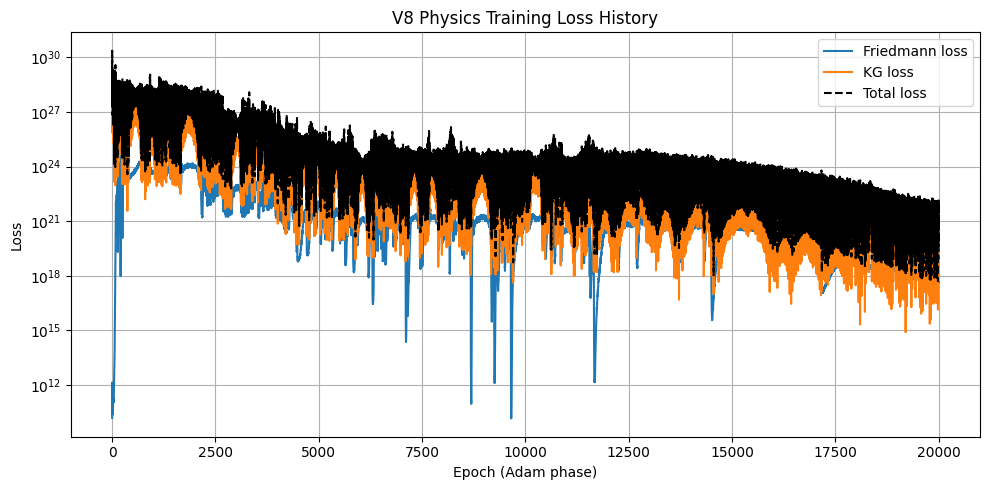

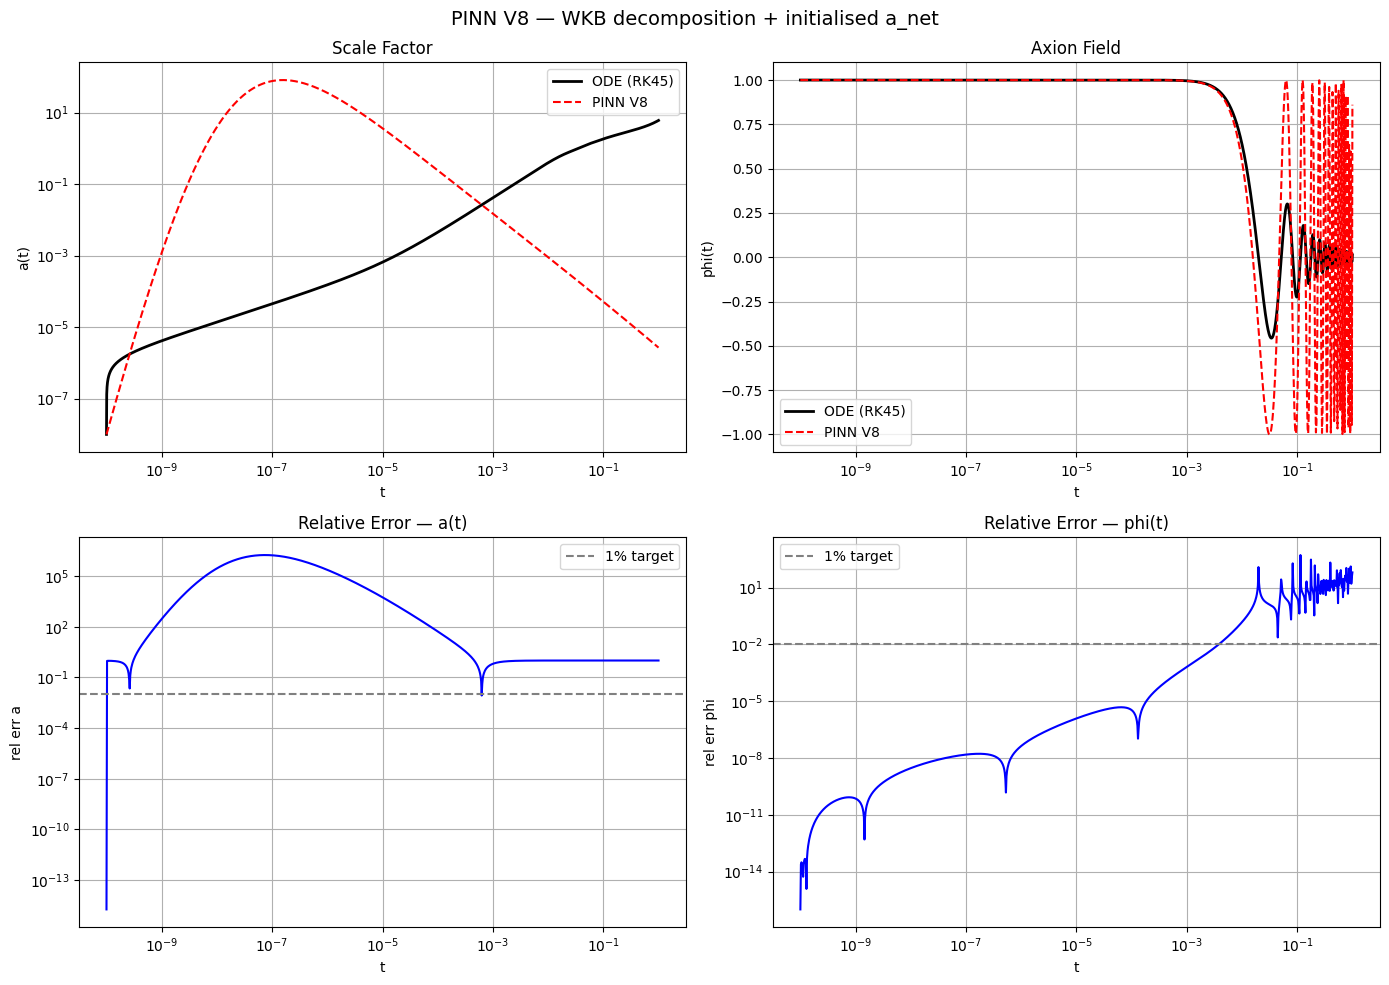

  Median rel-err a:   9.421e+01
  Median rel-err phi: 1.077e-06
  Max    rel-err a:   1.762e+06
  Max    rel-err phi: 5.225e+02


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION + PLOTS
# ─────────────────────────────────────────────────────────────────────────────
plot_loss_v9(solver_v9,    save_dir="results_v9")
plot_results_v9(solver_v9, save_dir="results_v9")
